# Week 8: Recurrent Neural Networks and LSTMs

## The memory problem in feedforward networks

Every network we have seen so far — dense layers, convolutional layers — processes each input independently. Feed it a vector, get a prediction. Feed it another vector, get another prediction. Nothing from the first prediction carries over to influence the second.

For many problems that is fine. Predicting house prices, classifying an image, diagnosing a tumor — each example is self-contained.

But a large class of real-world problems are **sequential**: the meaning of an input depends on what came before it.

- In a sentence, the pronoun "it" only makes sense if you remember what noun appeared earlier.
- In a time series, tomorrow's sensor reading depends on the trend of the last ten readings.
- In music, the next note sounds right or wrong depending on the notes that preceded it.

A feedforward network has no memory. You can work around this by concatenating the last N inputs into one big vector and feeding that in — and that is exactly what we do in the ARIMA notebook for time series. But that approach has a fixed window. If the dependency you care about is 50 steps back, you need a 50-step window, which explodes the input size and still ignores anything beyond that horizon.

Recurrent Neural Networks solve this with a different design: they pass a **hidden state** forward through the sequence, so every prediction can draw on everything the network has seen so far.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

## RNN architecture

An RNN processes a sequence one step at a time. At each time step $t$ it receives the current input $x_t$ and the previous hidden state $h_{t-1}$, and it produces a new hidden state:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

The tanh squashes the result into $(-1, 1)$ — the same activation we highlighted in the activation functions notebook for its use in recurrent networks.

A critical point: **the same weight matrices $W_h$ and $W_x$ are reused at every timestep**. This is called *weight sharing over time*. It means the number of parameters is constant regardless of how long the sequence is, and it means the network learns the same "how to update my memory" rule that it applies at every step.

Here is what that looks like unrolled across a short sequence:

```
Input:       x_1          x_2          x_3          x_4
              |            |            |            |
            [W_x]        [W_x]        [W_x]        [W_x]
              |            |            |            |
h_0 -[W_h]-> (+) -tanh-> h_1 -[W_h]-> (+) -tanh-> h_2 -[W_h]-> (+) -tanh-> h_3 -[W_h]-> (+) -tanh-> h_4
                                                                                                          |
                                                                                                       output
```

Each `(+)` is an element-wise sum. Each box `[W_h]` and `[W_x]` is the same matrix applied at every step — only the inputs and hidden states change.

After processing the full sequence, the final hidden state $h_T$ is a compressed summary of everything the network has read. For sequence-to-one tasks (like predicting the next value in a time series) you use just $h_T$. For sequence-to-sequence tasks (like translating a sentence) you can use all of $h_1, h_2, \ldots, h_T$.

## The vanishing gradient problem in RNNs

Training an RNN requires backpropagating gradients *through time* — unrolling the network into a long chain and applying the chain rule across every step.

Recall from the activation functions notebook that sigmoid and tanh both have regions where the gradient becomes very small. When you multiply many small numbers together — one per timestep — the result shrinks toward zero exponentially fast. By the time the gradient reaches early timesteps, it is so small that the weights there barely update.

In practice, a basic ("vanilla") RNN can learn relationships between inputs that are 10–15 steps apart, but not much more. Anything farther back is effectively invisible to the training signal.

This is a direct consequence of multiplying the same weight matrix $W_h$ through many steps. If the largest singular value of $W_h$ is less than 1, gradients vanish. If it is greater than 1, gradients explode (which is a different, equally destabilizing problem).

The solution is to change the architecture so that information can travel across long distances *without* passing through that multiplicative bottleneck at every step. That is exactly what LSTMs do.

## LSTM — Long Short-Term Memory

An LSTM adds a second internal channel called the **cell state** $C_t$, often described as a "conveyor belt" that carries information through the sequence.

```
                       C_{t-1} ----[forget]----(+)----> C_t ---------> ...
                                                 |
                                              [input]
                                                 |
  x_t ----\                               [new candidate]
           (concat) --gates--------------->
  h_{t-1}-/                                    [output]
                                                 |
                       h_{t-1} ................> h_t -----------> ...
```

The key design: the cell state is modified **additively** — information is written to it or removed from it, but at each step the update is a controlled addition, not a full matrix multiplication applied to everything. This means gradients can flow backward through $C_t$ across hundreds of steps without vanishing.

Three **gates** control what happens to the cell state. Each gate is a learned sigmoid layer (output between 0 and 1) that acts like a valve:

### Forget gate

Looks at the current input and the previous hidden state, and decides which parts of the cell state to erase. An output near 0 means "forget this"; near 1 means "keep this intact."

Intuition: if the network is processing a sentence and just finished a paragraph about one topic, the forget gate can wipe the cell state before starting the next paragraph.

### Input gate

Decides what new information to write into the cell state. It has two components: a sigmoid layer that decides *which values* to update, and a tanh layer that produces a vector of *candidate values* to potentially add.

Intuition: the network just read "the president of France" — the input gate writes "current subject = French president" into the cell state, replacing whatever the forget gate erased.

### Output gate

Decides which parts of the cell state to expose as the hidden state $h_t$ — the part that gets passed to the next timestep and used to make predictions. The cell state may hold many facts; the output gate selects what is relevant right now.

Intuition: the model is about to predict the next word. The output gate pulls the relevant part of its memory — the current grammatical subject, the tense of the verb it just saw — and exposes that as $h_t$.

---

You do not need to memorize the gate equations. The key insight is: **the LSTM learns to decide what to remember, what to forget, and what to use, all from data**. Those decisions are made by the gates, which are themselves neural network layers trained end-to-end by backpropagation.

## Implementation: predicting a noisy sine wave

We will build an LSTM that takes the last 30 points of a noisy sine wave and predicts the next value. This is a **sequence-to-one** task: a window of inputs, a single output.

The sine wave is a clean test case for sequence models because:
- The correct prediction genuinely depends on recent history (you need to know where you are in the cycle).
- A feedforward network with a fixed window can learn it, but only if you give it a window long enough to span the period.
- An LSTM can learn the periodic structure and generalize.

We will add Gaussian noise so the task is not trivially easy.

In [2]:
# Generate the dataset

WINDOW = 30       # input sequence length
N_POINTS = 2000   # total number of points in the sine wave
NOISE_STD = 0.1

t = np.linspace(0, 8 * np.pi, N_POINTS)
signal = np.sin(t) + np.random.normal(0, NOISE_STD, size=N_POINTS)

# Build sliding-window sequences
X, y = [], []
for i in range(len(signal) - WINDOW):
    X.append(signal[i : i + WINDOW])
    y.append(signal[i + WINDOW])

X = np.array(X)[..., np.newaxis]  # shape: (samples, timesteps, features)
y = np.array(y)

# Train / validation split (first 80% train)
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print(f"Training sequences:   {X_train.shape}")
print(f"Validation sequences: {X_val.shape}")
print(f"Each sequence shape:  {X_train[0].shape}  (timesteps, features)")

Training sequences:   (1576, 30, 1)
Validation sequences: (394, 30, 1)
Each sequence shape:  (30, 1)  (timesteps, features)


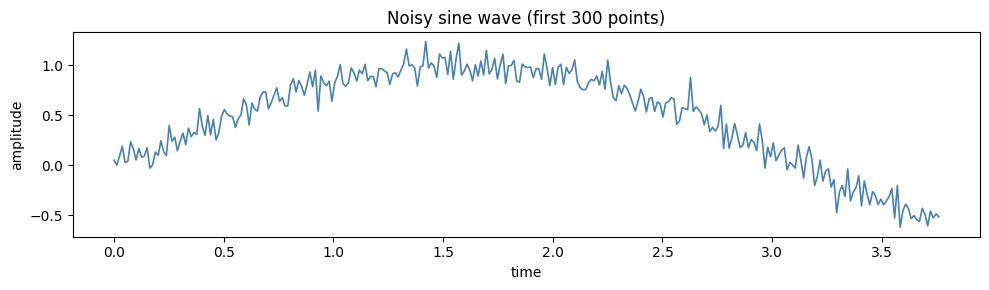

In [3]:
# Plot a snippet of the raw signal to see what we are working with
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t[:300], signal[:300], color='steelblue', linewidth=1.2)
ax.set_xlabel('time')
ax.set_ylabel('amplitude')
ax.set_title('Noisy sine wave (first 300 points)')
plt.tight_layout()
plt.show()

## Building the LSTM model

The architecture is straightforward:

1. **LSTM layer** — processes the 30-timestep input sequence and outputs a single hidden state vector at the final timestep.
2. **Dense layer** — a single output neuron producing the predicted next value (regression, no activation).

`tf.keras.layers.LSTM(n_units)` handles all the gate arithmetic internally. You only specify the number of units (the dimensionality of the hidden state and cell state).

In [4]:
def build_lstm_model(n_units):
    model = keras.Sequential([
        layers.Input(shape=(WINDOW, 1)),
        layers.LSTM(n_units),
        layers.Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Preview the architecture with 32 units
build_lstm_model(32).summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 lstm (LSTM)                 (None, 32)                4352      


 dense (Dense)               (None, 1)                 33        


Total params: 4385 (17.13 KB)


Trainable params: 4385 (17.13 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


Notice the parameter count. An LSTM layer with 32 units on a 1-feature input has:

$$4 \times (n_{\text{units}} \times (n_{\text{input}} + n_{\text{units}}) + n_{\text{units}})$$

The factor of 4 comes from the four gates (forget, input, cell candidate, output) — each is a separate learned linear layer. This is more expensive per unit than a dense layer, but the hidden state is shared across all 30 timesteps, so the total is still modest.

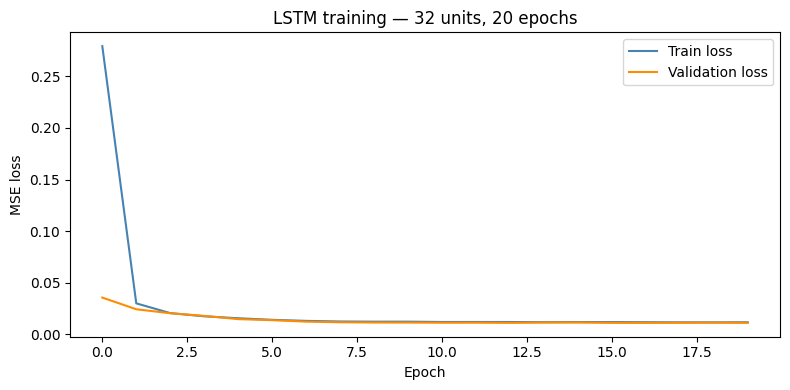

In [5]:
# Train a baseline model and plot predictions vs. ground truth

baseline_model = build_lstm_model(32)

history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    verbose=0
)

# Plot train vs. validation loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Train loss',      color='steelblue')
ax.plot(history.history['val_loss'], label='Validation loss', color='darkorange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('LSTM training — 32 units, 20 epochs')
ax.legend()
plt.tight_layout()
plt.show()

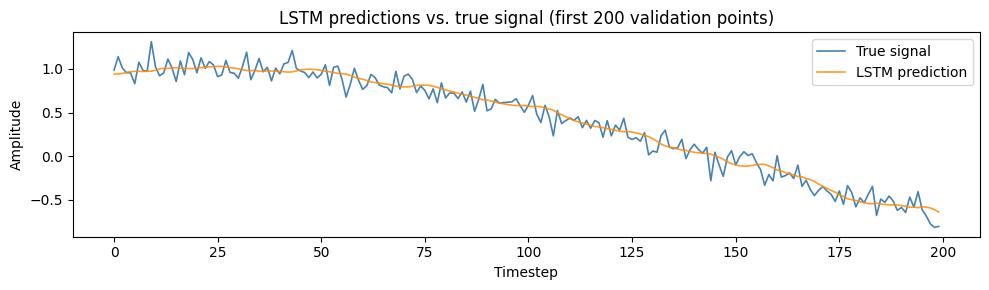

Validation MSE: 0.01105


In [6]:
# Compare predictions vs. ground truth on the validation set

y_pred = baseline_model.predict(X_val, verbose=0).flatten()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(y_val[:200],  label='True signal', color='steelblue',  linewidth=1.2)
ax.plot(y_pred[:200], label='LSTM prediction', color='darkorange', linewidth=1.2, alpha=0.85)
ax.set_xlabel('Timestep')
ax.set_ylabel('Amplitude')
ax.set_title('LSTM predictions vs. true signal (first 200 validation points)')
ax.legend()
plt.tight_layout()
plt.show()

val_mse = np.mean((y_pred - y_val) ** 2)
print(f"Validation MSE: {val_mse:.5f}")

## Interactive widget: effect of LSTM units on training

The number of units controls the dimensionality of the hidden state and cell state — in effect, how much memory the LSTM has available at each timestep.

Fewer units: the model has a compact memory and trains faster, but may underfit if the task requires holding several pieces of information at once.

More units: larger memory capacity and more expressive power, but more parameters to train and potentially slower convergence on small datasets.

Use the slider below to retrain with different numbers of units and observe how the loss curves change.

In [7]:
units_slider = widgets.IntSlider(
    value=32,
    min=16, max=128, step=16,
    description='LSTM units:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px')
)

train_button = widgets.Button(
    description='Train',
    button_style='primary',
    layout=widgets.Layout(width='100px')
)

status_label = widgets.Label(value='Click Train to start.')
output = widgets.Output()

def on_train_clicked(b):
    n_units = units_slider.value
    status_label.value = f'Training LSTM with {n_units} units…'
    train_button.disabled = True

    model = build_lstm_model(n_units)
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=64,
        verbose=0
    )

    y_pred_w = model.predict(X_val, verbose=0).flatten()
    final_val_mse = hist.history['val_loss'][-1]

    with output:
        clear_output(wait=True)

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        axes[0].plot(hist.history['loss'],     label='Train',      color='steelblue')
        axes[0].plot(hist.history['val_loss'], label='Validation', color='darkorange')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('MSE loss')
        axes[0].set_title(f'Loss curves — {n_units} units')
        axes[0].legend()

        axes[1].plot(y_val[:200],   label='True signal',    color='steelblue',  linewidth=1.2)
        axes[1].plot(y_pred_w[:200], label='LSTM prediction', color='darkorange', linewidth=1.2, alpha=0.85)
        axes[1].set_xlabel('Timestep')
        axes[1].set_ylabel('Amplitude')
        axes[1].set_title(f'Predictions — {n_units} units  (val MSE: {final_val_mse:.5f})')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    status_label.value = f'Done. Final validation MSE: {final_val_mse:.5f}'
    train_button.disabled = False

train_button.on_click(on_train_clicked)

display(widgets.VBox([
    widgets.HBox([units_slider, train_button]),
    status_label,
    output
]))

A few things to look for as you experiment:

- With 16 units, the model still learns the sine wave reasonably well. The sine task is not that complex — you mainly need to track where you are in the current cycle.
- With 64 or more units, you may see faster convergence in early epochs, but the validation loss might not improve much beyond 32 units. The task does not require a large memory.
- If train loss falls but validation loss plateaus or rises, you are starting to overfit — the model has memorized training sequences rather than learning the underlying periodicity.

## Sequence-to-one vs. sequence-to-sequence

The sine wave task above is **sequence-to-one**: the LSTM reads 30 timesteps and produces a single output at the end. This is what `layers.LSTM(n_units)` does by default — it returns only the final hidden state.

Many tasks need an output at *every* timestep:

- **Part-of-speech tagging**: label each word in a sentence as noun, verb, adjective, etc.
- **Named entity recognition**: mark each word as person, location, organization, or other.
- **Sequence-to-sequence translation** (with an encoder-decoder): the encoder reads the source sentence into a context vector; the decoder generates one output token per step.

In Keras, switching to sequence-to-sequence output requires one argument change:

In [8]:
# return_sequences=False (default): only the final hidden state is returned
seq_to_one = keras.Sequential([
    layers.Input(shape=(WINDOW, 1)),
    layers.LSTM(32),                         # output shape: (batch, 32)
    layers.Dense(1)
])

# return_sequences=True: a hidden state is returned for every timestep
seq_to_seq = keras.Sequential([
    layers.Input(shape=(WINDOW, 1)),
    layers.LSTM(32, return_sequences=True),  # output shape: (batch, 30, 32)
    layers.Dense(1)                          # applied independently at each timestep
])

print("Sequence-to-one output shape:",
      seq_to_one.output_shape)   # (None, 1)
print("Sequence-to-seq output shape:",
      seq_to_seq.output_shape)   # (None, 30, 1)

Sequence-to-one output shape: (None, 1)
Sequence-to-seq output shape: (None, 30, 1)


When stacking multiple LSTM layers, all but the last one must use `return_sequences=True`, so that the next LSTM layer receives a full sequence rather than just a single vector:

In [9]:
stacked_lstm = keras.Sequential([
    layers.Input(shape=(WINDOW, 1)),
    layers.LSTM(32, return_sequences=True),  # passes full sequence to next layer
    layers.LSTM(16),                         # consumes full sequence, outputs final state
    layers.Dense(1)
])

stacked_lstm.summary()

Model: "sequential_4"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 lstm_4 (LSTM)               (None, 30, 32)            4352      


 lstm_5 (LSTM)               (None, 16)                3136      


 dense_4 (Dense)             (None, 1)                 17        


Total params: 7505 (29.32 KB)


Trainable params: 7505 (29.32 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


## Summary

Here is the architecture story from this notebook:

| Model | Memory | Long-range learning | Notes |
|---|---|---|---|
| Feedforward (dense) | None | No | Each example processed independently |
| Vanilla RNN | Hidden state $h_t$ | Poor — vanishing gradient | Weights shared across timesteps; gradient shrinks exponentially |
| LSTM | Hidden state $h_t$ + cell state $C_t$ | Yes — additive cell updates | Three gates learn what to remember, forget, and expose |

The LSTM's cell state is the key. Because it is modified additively through gated write/erase operations rather than through a full matrix multiplication at every step, gradients can flow backward through it without shrinking. That lets the network learn to connect inputs that are separated by many timesteps.

**Where do RNNs fit today?**

For long-sequence NLP tasks, Transformer-based models (BERT, GPT) have largely displaced LSTMs — they handle very long-range dependencies better and train faster because they process the whole sequence in parallel rather than step by step. But LSTMs are still widely used for time series, sensor data, and any sequential task where the sequence length is modest and you want a lightweight, well-understood model. They are also the conceptual foundation that makes Transformers easier to understand — the Transformer attention mechanism is, in one view, a smarter answer to the same question the LSTM was designed to answer.